# Buổi 5 · Tình huống 06 — Đề xuất miễn phí vận chuyển (Adaline)

Notebook này dùng lại bối cảnh trong [`bai-tap/buoi4-tinh-huong/06_mien_phi_van_chuyen.py`](../../bai-tap/buoi4-tinh-huong/06_mien_phi_van_chuyen.py), nhưng thay Perceptron (0/1) bằng **Adaline** học quy tắc Widrow–Hoff (LMS) với **target liên tục**.

Không có dữ liệu hoặc lời giải dựng sẵn trong notebook này. Các code cell chỉ chứa comment định hướng; bạn tự thu thập dữ liệu, xử lý, huấn luyện, đánh giá và triển khai thử.

## Bối cảnh

Một cửa hàng muốn tạo quy tắc đề xuất đơn hàng có được miễn phí vận chuyển.

Feature có thể cân nhắc: giá trị đơn hàng, khoảng cách giao, hạng thành viên, khối lượng kiện hàng (chuẩn hoá).

## Vì sao dùng Adaline thay Perceptron?

Thay vì chỉ 0/1 (trả phí / miễn phí), hãy coi target là **mức giảm phí vận chuyển** trong [0, 1] (0 = trả đủ phí, 1 = miễn phí hoàn toàn), cho phép giảm phí một phần.

Nhắc lại công thức Adaline / Widrow–Hoff:

$$
\text{net} = \mathbf{w}^\top \mathbf{x} + b, \qquad e = t - \text{net}
$$

$$
\mathbf{w} \leftarrow \mathbf{w} + \eta e \mathbf{x}, \qquad b \leftarrow b + \eta e
$$

Mức giảm phí liên tục linh hoạt hơn quy tắc miễn phí toàn phần/không của Perceptron, phù hợp với các chính sách giảm giá theo bậc.

## Nhiệm vụ suy nghĩ

1. Xác định feature nào kéo mức giảm phí về gần 0 hoặc gần 1.
2. Tạo các mẫu gần ranh giới, không chỉ tạo các trường hợp quá dễ.
3. Huấn luyện Adaline và viết lại net = wᵀx + b của một đơn hàng bằng phép tính tay.
4. Thay đổi learning rate (eta), quan sát số epoch cần để MSE hội tụ.
5. Kiểm tra quy tắc học được có tạo ra quyết định khó giải thích hay không.

Không có code mẫu hoặc lời giải trong notebook này. Bắt đầu phần triển khai ở các cell dưới.

## 1. Thu thập / tạo dữ liệu

Tự tạo hoặc thu thập một bảng dữ liệu nhỏ. Ghi rõ ý nghĩa, đơn vị của từng feature và cách bạn gán target liên tục (không chỉ 0/1).

In [1]:
import numpy as np
import pandas as pd

from pathlib import Path

DATA_PATH = Path("../../data/ecommerce_sales_34500.csv")

df = pd.read_csv(DATA_PATH)

df["order_date"] = pd.to_datetime(
    df["order_date"],
    errors="coerce"
)

df = df.sort_values(
    ["customer_id", "order_date", "order_id"]
).reset_index(drop=True)

df["previous_spending"] = (
    df.groupby("customer_id")["total_amount"]
    .cumsum()
    - df["total_amount"]
)

df["previous_orders"] = (
    df.groupby("customer_id")
    .cumcount()
)


def create_membership(
    previous_spending,
    previous_orders
):
    if previous_spending >= 1500 or previous_orders >= 8:
        return "VIP"
    elif previous_spending >= 800 or previous_orders >= 5:
        return "Gold"
    elif previous_spending >= 300 or previous_orders >= 2:
        return "Silver"
    else:
        return "Bronze"


df["membership_level"] = [
    create_membership(
        spending,
        orders
    )
    for spending, orders in zip(
        df["previous_spending"],
        df["previous_orders"]
    )
]

np.random.seed(42)

df["distance_km"] = np.random.uniform(
    1,
    30,
    len(df)
)

membership_map = {
    "Bronze": 0,
    "Silver": 1,
    "Gold": 2,
    "VIP": 3
}

df["membership_code"] = (
    df["membership_level"]
    .map(membership_map)
)


def create_target(row):
    high_value = row["total_amount"] >= 100
    loyal_customer = (
        row["membership_level"]
        in ["Gold", "VIP"]
    )
    short_distance = (
        row["distance_km"] <= 10
    )
    reasonable_order = (
        row["total_amount"] >= 70
    )

    if high_value and short_distance:
        return 1

    if (
        loyal_customer
        and short_distance
        and reasonable_order
    ):
        return 1

    return 0


df["y"] = df.apply(
    create_target,
    axis=1
)

X = df[
    [
        "total_amount",
        "distance_km",
        "membership_code"
    ]
].to_numpy(
    dtype=float
)

t = df["y"].to_numpy(
    dtype=float
)

print("X shape:", X.shape)
print("t shape:", t.shape)

print("\nFirst 5 X:")
print(X[:5])

print("\nFirst 5 target:")
print(t[:5])


X shape: (34500, 3)
t shape: (34500,)

First 5 X:
[[ 33.12        11.86166345   0.        ]
 [177.46        28.57071489   0.        ]
 [676.86        22.22782431   0.        ]
 [205.76        18.36109604   1.        ]
 [562.68         5.52454057   2.        ]]

First 5 target:
[0. 0. 0. 0. 1.]


## 2. Chuẩn hoá feature

Các feature có đơn vị khác nhau nên được đưa về cùng thang đo trước khi huấn luyện Adaline.

In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Before scaling:")
print(X[:5])

print("\nAfter scaling:")
print(X_scaled[:5])

print("\nMean:")
print(
    np.round(
        X_scaled.mean(axis=0),
        4
    )
)

print("\nStd:")
print(
    np.round(
        X_scaled.std(axis=0),
        4
    )
)


Before scaling:
[[ 33.12        11.86166345   0.        ]
 [177.46        28.57071489   0.        ]
 [676.86        22.22782431   0.        ]
 [205.76        18.36109604   1.        ]
 [562.68         5.52454057   2.        ]]

After scaling:
[[-0.3829072  -0.43378916 -0.969299  ]
 [ 0.0208435   1.56642012 -0.969299  ]
 [ 1.41777504  0.80712456 -0.969299  ]
 [ 0.10000482  0.34424575  0.16725456]
 [ 1.09838849 -1.19239428  1.30380813]]

Mean:
[-0. -0.  0.]

Std:
[1. 1. 1.]


## 3. Tách train/test

Tách dữ liệu trước khi huấn luyện để có thể đánh giá khách quan.

In [3]:
split_index = int(
    len(X_scaled) * 0.8
)

X_train = X_scaled[
    :split_index
]

X_test = X_scaled[
    split_index:
]

t_train = t[
    :split_index
]

t_test = t[
    split_index:
]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("t_train:", t_train.shape)
print("t_test:", t_test.shape)

print("\nTrain target distribution:")
print(
    pd.Series(
        t_train
    ).value_counts()
)

print("\nTest target distribution:")
print(
    pd.Series(
        t_test
    ).value_counts()
)


X_train: (27600, 3)
X_test: (6900, 3)
t_train: (27600,)
t_test: (6900,)

Train target distribution:
0.0    24342
1.0     3258
Name: count, dtype: int64

Test target distribution:
0.0    6071
1.0     829
Name: count, dtype: int64


## 4. Cài đặt và huấn luyện Adaline

Viết (hoặc tái sử dụng) một bước cập nhật Widrow–Hoff, rồi huấn luyện qua nhiều epoch và theo dõi MSE.

In [4]:
learning_rate = 0.001
epochs = 50

w = np.zeros(
    X_train.shape[1],
    dtype=float
)

b = 0.0

train_mse_history = []
test_mse_history = []

for epoch in range(epochs):

    squared_errors = []

    for i in range(
        len(X_train)
    ):

        x_i = X_train[i]
        t_i = t_train[i]

        net = np.dot(
            w,
            x_i
        ) + b

        e = t_i - net

        w = (
            w
            + learning_rate
            * e
            * x_i
        )

        b = (
            b
            + learning_rate
            * e
        )

        squared_errors.append(
            e ** 2
        )

    train_output = (
        np.dot(
            X_train,
            w
        ) + b
    )

    test_output = (
        np.dot(
            X_test,
            w
        ) + b
    )

    train_mse = np.mean(
        (
            t_train
            - train_output
        ) ** 2
    )

    test_mse = np.mean(
        (
            t_test
            - test_output
        ) ** 2
    )

    train_mse_history.append(
        train_mse
    )

    test_mse_history.append(
        test_mse
    )

print("Learning rate:", learning_rate)
print("Epochs:", epochs)

print("\nWeights:")
print(w)

print("\nBias:")
print(b)

print(
    "\nFinal train MSE:",
    train_mse_history[-1]
)

print(
    "Final test MSE:",
    test_mse_history[-1]
)


Learning rate: 0.001
Epochs: 50

Weights:
[ 0.07590257 -0.14673144  0.00741543]

Bias:
0.11668065119089449

Final train MSE: 0.0784322779141782
Final test MSE: 0.08104730439008137


## 5. Vẽ đường học (MSE theo epoch)

Quan sát MSE có giảm dần và ổn định hay không.

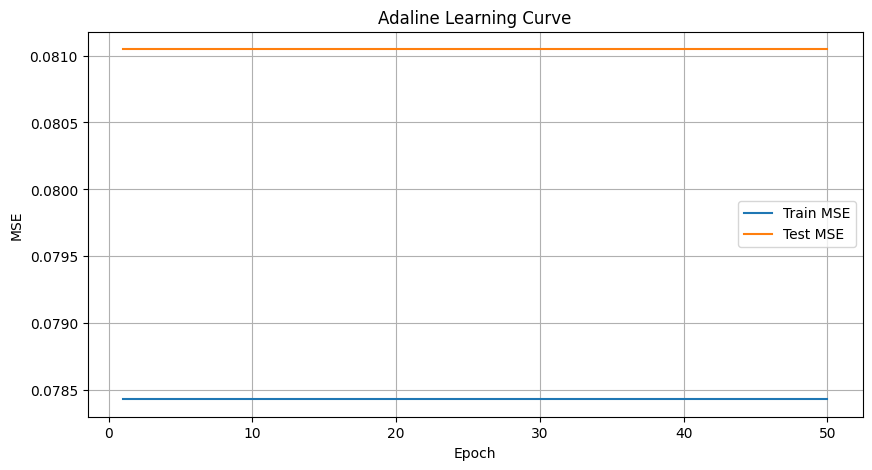

Initial Train MSE: 0.078432
Final Train MSE: 0.078432


In [5]:
import matplotlib.pyplot as plt

epoch_range = np.arange(
    1,
    epochs + 1
)

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    epoch_range,
    train_mse_history,
    label="Train MSE"
)

plt.plot(
    epoch_range,
    test_mse_history,
    label="Test MSE"
)

plt.xlabel("Epoch")
plt.ylabel("MSE")

plt.title(
    "Adaline Learning Curve"
)

plt.legend()

plt.grid(True)

plt.show()

print(
    "Initial Train MSE:",
    round(
        train_mse_history[0],
        6
    )
)

print(
    "Final Train MSE:",
    round(
        train_mse_history[-1],
        6
    )
)


## 6. Đánh giá và phân tích

Xem lại các mẫu có sai số dự đoán lớn nhất, đọc dấu của trọng số và đối chiếu với trực giác nghiệp vụ.

In [7]:
test_output = (
    np.dot(
        X_test,
        w
    ) + b
)

test_error = (
    t_test
    - test_output
)

absolute_error = np.abs(
    test_error
)

error_df = pd.DataFrame({
    "actual": t_test,
    "prediction_continuous": test_output,
    "error": test_error,
    "absolute_error": absolute_error
})

largest_errors = (
    error_df
    .sort_values(
        "absolute_error",
        ascending=False
    )
    .head(3)
)

print("=" * 60)
print("ADALINE ANALYSIS")
print("=" * 60)

print("\nWeights:")

feature_names = [
    "total_amount",
    "distance_km",
    "membership_code"
]

for feature, weight in zip(
    feature_names,
    w
):
    print(
        f"{feature}: {weight:.6f}"
    )

print(
    "\nBias:",
    round(b, 6)
)

print(
    "\nLargest 3 errors:"
)

print(
    largest_errors.to_string(
        index=False
    )
)


ADALINE ANALYSIS

Weights:
total_amount: 0.075903
distance_km: -0.146731
membership_code: 0.007415

Bias: 0.116681

Largest 3 errors:
 actual  prediction_continuous     error  absolute_error
    0.0               2.722476 -2.722476        2.722476
    0.0               1.197918 -1.197918        1.197918
    0.0               1.049477 -1.049477        1.049477


## 7. Chọn ngưỡng và thử nghiệm

Nếu cần một quyết định rời rạc (ví dụ cảnh báo/không cảnh báo) từ điểm liên tục, hãy chọn ngưỡng phù hợp và giải thích lựa chọn.

In [8]:
threshold = 0.5

y_pred = (
    test_output >= threshold
).astype(int)

accuracy = np.mean(
    y_pred == t_test
)

cm = np.zeros(
    (2, 2),
    dtype=int
)

for actual, predicted in zip(
    t_test.astype(int),
    y_pred
):
    cm[
        actual,
        predicted
    ] += 1

tn = cm[0, 0]
fp = cm[0, 1]
fn = cm[1, 0]
tp = cm[1, 1]

recall = (
    tp / (tp + fn)
    if (tp + fn) > 0
    else 0
)

print("=" * 60)
print("THRESHOLD EXPERIMENT")
print("=" * 60)

print(
    "Threshold:",
    threshold
)

print(
    "Accuracy:",
    round(
        accuracy,
        4
    )
)

print(
    "Recall:",
    round(
        recall,
        4
    )
)

print("\nConfusion Matrix:")
print(cm)

print(
    "\nTN:",
    tn
)

print(
    "FP:",
    fp
)

print(
    "FN:",
    fn
)

print(
    "TP:",
    tp
)


def predict_one(
    total_amount,
    distance_km,
    membership_level
):

    membership_map = {
        "Bronze": 0,
        "Silver": 1,
        "Gold": 2,
        "VIP": 3
    }

    if membership_level not in membership_map:
        raise ValueError(
            "Invalid membership level"
        )

    if total_amount < 0:
        raise ValueError(
            "total_amount must be >= 0"
        )

    if (
        distance_km <= 0
        or distance_km > 30
    ):
        raise ValueError(
            "distance_km must be in the range (0, 30]"
        )

    sample = np.array([
        [
            total_amount,
            distance_km,
            membership_map[
                membership_level
            ]
        ]
    ], dtype=float)

    sample_scaled = scaler.transform(
        sample
    )

    net = float(
        np.dot(
            w,
            sample_scaled[0]
        ) + b
    )

    prediction = int(
        net >= threshold
    )

    decision = (
        "Free Shipping"
        if prediction == 1
        else "Voucher"
    )

    return {
        "net": net,
        "prediction": prediction,
        "decision": decision
    }


samples = [
    (
        200,
        6,
        "Gold"
    ),
    (
        60,
        25,
        "Bronze"
    ),
    (
        80,
        8,
        "VIP"
    )
]

for sample in samples:

    result = predict_one(
        total_amount=sample[0],
        distance_km=sample[1],
        membership_level=sample[2]
    )

    print("\nInput:")
    print(
        "total_amount =",
        sample[0]
    )

    print(
        "distance_km =",
        sample[1]
    )

    print(
        "membership_level =",
        sample[2]
    )

    print(
        "net =",
        result["net"]
    )

    print(
        "prediction =",
        result["prediction"]
    )

    print(
        "decision =",
        result["decision"]
    )


THRESHOLD EXPERIMENT
Threshold: 0.5
Accuracy: 0.8819
Recall: 0.0603

Confusion Matrix:
[[6035   36]
 [ 779   50]]

TN: 6035
FP: 36
FN: 779
TP: 50

Input:
total_amount = 200
distance_km = 6
membership_level = Gold
net = 0.29932694634963963
prediction = 0
decision = Voucher

Input:
total_amount = 60
distance_km = 25
membership_level = Bronze
net = -0.0809873679496404
prediction = 0
decision = Voucher

Input:
total_amount = 80
distance_km = 8
membership_level = VIP
net = 0.24714715188353184
prediction = 0
decision = Voucher


## 8. Kết luận

Trả lời ngắn gọn: Adaline với target liên tục có phù hợp hơn Perceptron 0/1 cho tình huống này không? Vì sao? Còn giới hạn gì (ví dụ nếu quan hệ giữa feature và target là phi tuyến, có thể cần MLP)?